# In this notebook we will
- Load Bentham dataset (PAGE XML)
- Visualize pages
- Extract line regions
- Start preprocessing experiments

## But since the images in Bentham dataset are already:
- segmented into lines
- layout is detected
- cleanly structured

we would only need to preprocess the images, in the sense of: 
- grayscale normalization
- contrast normalization
- resizing (TrOCR input size)
- denoising
- binarization
- augmentation


In [1]:
# import necessary libraries
import os
from pathlib import Path

import cv2
import numpy as np
import matplotlib.pyplot as plt

from PIL import Image

In [2]:
# Path to my dataset
DATA_DIR = Path("data")

LINE_IMAGES_DIR = DATA_DIR / "BenthamDatasetR0-GT" / "Images" / "Lines"

# load Example image
IMAGE_PATH = next(LINE_IMAGES_DIR.glob("*.png"))

print(IMAGE_PATH)

data/BenthamDatasetR0-GT/Images/Lines/071_139_003_04_07.png


In [3]:
# I now develop a function to visualize an image
def show_image(img, title="", cmap="gray", figsize=(12,4)):
    plt.figure(figsize=figsize)
    plt.imshow(img, cmap=cmap)
    plt.title(title)
    plt.axis("off")
    plt.show()

Shape: (104, 1705)
Dtype: uint8


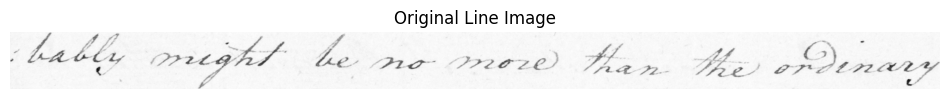

In [4]:
# Now I call the function to show the selected image with its properties (shape and type)
img = cv2.imread(str(IMAGE_PATH), cv2.IMREAD_GRAYSCALE)

print("Shape:", img.shape)
print("Dtype:", img.dtype)

show_image(img, "Original Line Image")

<class 'PIL.Image.Image'>


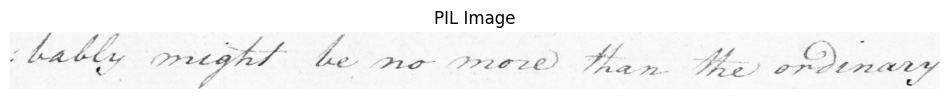

In [5]:
pil_img = Image.fromarray(img)

print(type(pil_img))
show_image(np.array(pil_img), "PIL Image")

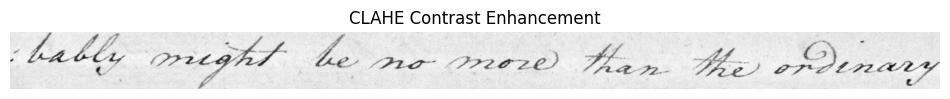

In [6]:
# To improve local contrast of the images, I apply CLAHE 
# (Contrast Limited Adaptive Histogram Equalization). 
# This is a specialized image preprocessing technique.

def apply_clahe(image):
    clahe = cv2.createCLAHE(
        clipLimit=2.0,
        tileGridSize=(8,8)
    )
    return clahe.apply(image)

clahe_img = apply_clahe(img)

show_image(clahe_img, "CLAHE Contrast Enhancement")

The resolution of the image is now improved significantly.

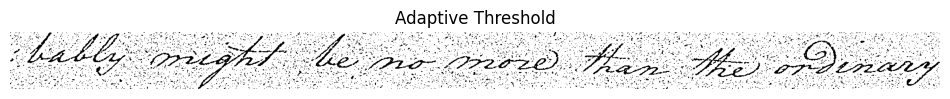

In [7]:
binary = cv2.adaptiveThreshold(
    img,
    255,
    cv2.ADAPTIVE_THRESH_GAUSSIAN_C,
    cv2.THRESH_BINARY,
    11,
    2
)

show_image(binary, "Adaptive Threshold")

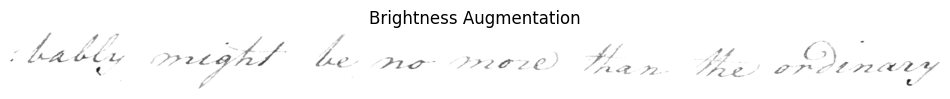

In [8]:
def adjust_brightness(image, alpha=1.2):
    return cv2.convertScaleAbs(
        image,
        alpha=alpha,
        beta=0
    )

bright = adjust_brightness(img)

show_image(
    bright,
    "Brightness Augmentation"
)

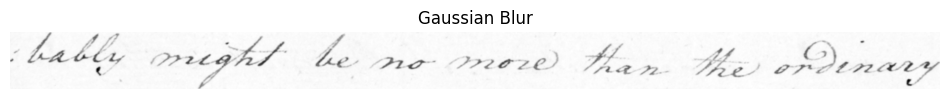

In [9]:
blurred = cv2.GaussianBlur(
    img,
    (3,3),
    0
)

show_image(
    blurred,
    "Gaussian Blur"
)

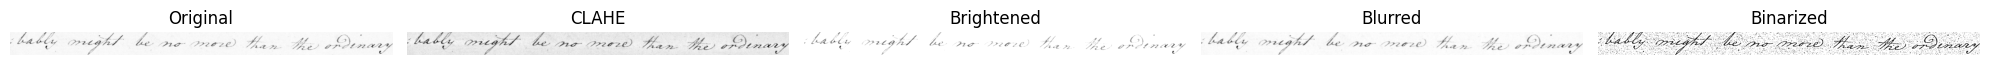

In [10]:
# side-by-side comparison
fig, ax = plt.subplots(1, 5, figsize=(20,10))

ax[0].imshow(img, cmap="gray")
ax[0].set_title("Original")

ax[1].imshow(clahe_img, cmap="gray")
ax[1].set_title("CLAHE")

ax[2].imshow(bright, cmap="gray")
ax[2].set_title("Brightened")

ax[3].imshow(blurred, cmap="gray")
ax[3].set_title("Blurred")

ax[4].imshow(binary, cmap="gray")
ax[4].set_title("Binarized")

for a in ax:
    a.axis("off")

plt.tight_layout()
plt.show()

I applied several preprocessing methods. but the fact is that many historical HTR studies find that excessive preprocessing can actually hurt modern Transformer OCR models, so it's worth measuring CER/WER before applying binarization or any other preprocessing steps.

In [11]:
from transformers import TrOCRProcessor

processor = TrOCRProcessor.from_pretrained(
    "microsoft/trocr-base-handwritten"
)

In [12]:
pixel_values = processor(
    pil_img,
    return_tensors="pt"
).pixel_values

print(pixel_values.shape)

torch.Size([1, 3, 384, 384])


The processor automatically:

- converts grayscale to RGB
- resizes to model input size
- normalizes
- creates tensors

so that we do not need to do these manually.

In [13]:
# We can now compare Preprocessing variants pixel values
variants = {
    "original": img,
    "clahe": clahe_img,
    "brightened": bright,
    "blurred": blurred,
    "binary": binary
}

for name, image in variants.items():

    pil_image = Image.fromarray(image)

    pixel_values = processor(
        pil_image,
        return_tensors="pt"
    ).pixel_values

    print(
        f"{name}: {pixel_values.shape}"
    )

original: torch.Size([1, 3, 384, 384])
clahe: torch.Size([1, 3, 384, 384])
brightened: torch.Size([1, 3, 384, 384])
blurred: torch.Size([1, 3, 384, 384])
binary: torch.Size([1, 3, 384, 384])


So the input size of all preprocessed variants of the image fits TrOCR model.
Now, we should create five preprocessing configurations, and feed those into the TrOCR model to compare CER and WER for the five cases: original, CLAHE, Brightened, Blurred, and Binarized ones. 

The output of this step would lead us to answer the question if preprocessing might help improve CER/WER? or would the original format work better with TrOCR. 

In [14]:
import torch
from transformers import VisionEncoderDecoderModel

import editdistance
from jiwer import wer

import pandas as pd
from tqdm import tqdm

In [15]:
model = VisionEncoderDecoderModel.from_pretrained(
    "microsoft/trocr-base-handwritten"
)

device = "cuda" if torch.cuda.is_available() else "cpu"
model.to(device)
model.eval()

Loading weights:   0%|          | 0/478 [00:00<?, ?it/s]

[transformers] VisionEncoderDecoderModel LOAD REPORT from: microsoft/trocr-base-handwritten
Key                         | Status  | 
----------------------------+---------+-
encoder.pooler.dense.bias   | MISSING | 
encoder.pooler.dense.weight | MISSING | 

Notes:
- MISSING:	those params were newly initialized because missing from the checkpoint. Consider training on your downstream task.


VisionEncoderDecoderModel(
  (encoder): ViTModel(
    (embeddings): ViTEmbeddings(
      (patch_embeddings): ViTPatchEmbeddings(
        (projection): Conv2d(3, 768, kernel_size=(16, 16), stride=(16, 16))
      )
      (dropout): Dropout(p=0.0, inplace=False)
    )
    (layers): ModuleList(
      (0-11): 12 x ViTLayer(
        (attention): ViTAttention(
          (q_proj): Linear(in_features=768, out_features=768, bias=False)
          (k_proj): Linear(in_features=768, out_features=768, bias=False)
          (v_proj): Linear(in_features=768, out_features=768, bias=False)
          (o_proj): Linear(in_features=768, out_features=768, bias=True)
        )
        (layernorm_before): LayerNorm((768,), eps=1e-12, elementwise_affine=True, bias=True)
        (layernorm_after): LayerNorm((768,), eps=1e-12, elementwise_affine=True, bias=True)
        (mlp): ViTMLP(
          (activation_fn): GELUActivation()
          (fc1): Linear(in_features=768, out_features=3072, bias=True)
          (fc2):

In [16]:
# metric evaluation (CER and WER computation function)
def cer(pred, gt):
    pred = pred.strip()
    gt = gt.strip()

    if len(gt) == 0:
        return 1.0

    return editdistance.eval(pred, gt) / len(gt)


def compute_wer(pred, gt):
    return wer(gt, pred)

In [17]:
# load ground-truth transcription alighned with text. files
TRANSCRIPTION_DIR = DATA_DIR / "BenthamDatasetR0-GT" / "Transcriptions"

def load_gt(image_path):

    file_name = image_path.stem + ".txt"
    gt_path = TRANSCRIPTION_DIR / file_name

    with open(gt_path, "r", encoding="utf-8") as f:
        text = f.read().strip()

    return text

In [ ]:
# call variants of the images

def preprocess_variants(image):

    variants = {}

    # Original
    variants["original"] = image

    # CLAHE
    variants["clahe"] = apply_clahe(image)

    # brightened
    variants["brightened"] = adjust_brightness(image)

    # Binarized
    variants["binary"] = cv2.adaptiveThreshold(image, 255,cv2.ADAPTIVE_THRESH_GAUSSIAN_C,cv2.THRESH_BINARY,11, 2)

    # Blurred
    variants["blurred"] = cv2.GaussianBlur(image,(3,3),0)

    return variants

In [25]:
# OCR inference function

def run_trocr(pil_image):

    pixel_values = processor(
        pil_image,
        return_tensors="pt"
    ).pixel_values.to(device)

    with torch.no_grad():
        generated_ids = model.generate(pixel_values)

    text = processor.batch_decode(
        generated_ids,
        skip_special_tokens=True
    )[0]

    return text

In [20]:
# single-image experiment
def evaluate_image(image_path):

    img = cv2.imread(str(image_path), cv2.IMREAD_GRAYSCALE)

    gt = load_gt(image_path)

    variants = preprocess_variants(img)

    results = []

    for name, image in variants.items():

        pil_img = Image.fromarray(image)

        pred = run_trocr(pil_img)

        results.append({
            "variant": name,
            "prediction": pred,
            "ground_truth": gt,
            "CER": cer(pred, gt),
            "WER": compute_wer(pred, gt)
        })

    return results

In [32]:
# run on small sample test images composed of the firts 20 images

sample_images = list(LINE_IMAGES_DIR.glob("*.png"))[:100]

all_results = []

for img_path in tqdm(sample_images):

    results = evaluate_image(img_path)

    all_results.extend(results)

  0%|          | 0/100 [00:00<?, ?it/s]/Users/hedyeh/Ginger_Gradient/Capstone-Project/.venv/lib/python3.11/site-packages/transformers/generation/utils.py:1612: UserWarning: Using the model-agnostic default `max_length` (=21) to control the generation length. We recommend setting `max_new_tokens` to control the maximum length of the generation.
  warnings.warn(
100%|██████████| 100/100 [05:03<00:00,  3.04s/it]


In [33]:
# results table
df = pd.DataFrame(all_results)
df.head()

,variant,prediction,ground_truth,CER,WER
0,original,bably insight he no more than the ordinary,: bably might be no more than the ordinary,0.142857,0.333333
1,clahe,bably insight he no more than the ordinary,: bably might be no more than the ordinary,0.142857,0.333333
2,brightened,bably insight he no more than their ordinary,: bably might be no more than the ordinary,0.190476,0.444444
3,binary,bably bright he no more than the ordinary,: bably might be no more than the ordinary,0.119048,0.333333
4,blurred,bably insight he no more than the ordinary,: bably might be no more than the ordinary,0.142857,0.333333


In [35]:
# aggregate metrics: key comparison output
summary = df.groupby("variant")[["CER", "WER"]].mean()
summary['CER_std'] = df.groupby("variant")[["CER"]].std()
summary['WER_std'] = df.groupby("variant")[["WER"]].std()

summary

,CER,WER,CER_std,WER_std
variant,,,,
binary,0.290010,0.385583,0.448742,0.331343
blurred,0.260565,0.366852,0.395971,0.315155
brightened,0.253896,0.372771,0.413035,0.396783
clahe,0.254253,0.344623,0.440914,0.392558
original,0.250278,0.348478,0.402585,0.318426


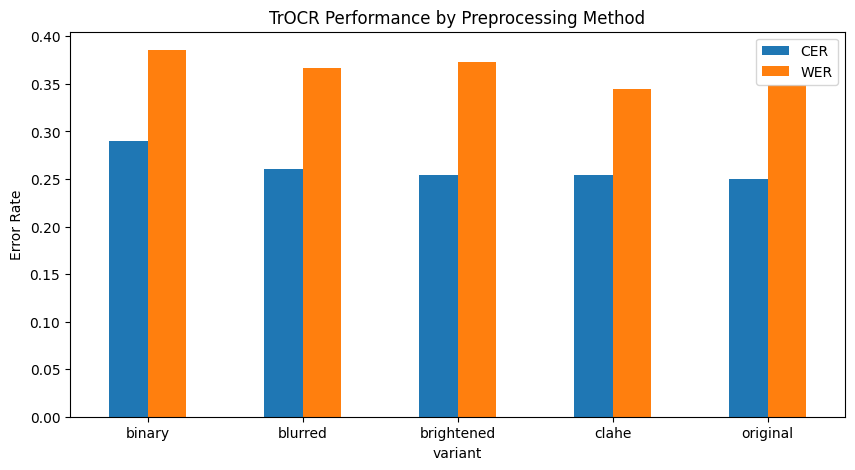

In [41]:
# plot the summary as bar 
means = summary[["CER", "WER"]]

means.plot(kind="bar", figsize=(10, 5))

plt.title("TrOCR Performance by Preprocessing Method")
plt.ylabel("Error Rate")
plt.xticks(rotation=0)
plt.show()

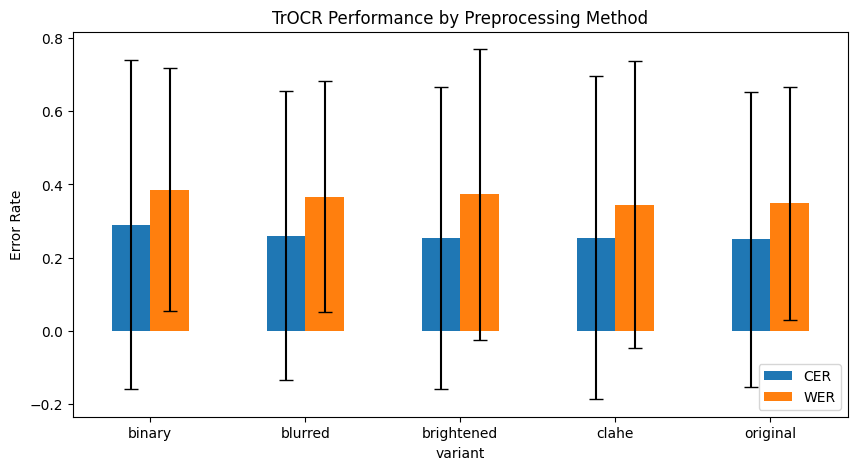

In [ ]:
# plot the summary with errorbar on each bar
means = summary[["CER", "WER"]]
errors = summary[["CER_std", "WER_std"]].values.T

means.plot(
    kind="bar", 
    yerr=errors, 
    figsize=(10, 5), 
    capsize=5,          
    ecolor="black"   
)
plt.title("TrOCR Performance by Preprocessing Method")
plt.ylabel("Error Rate")
plt.xticks(rotation=0)
plt.show()

| Outcome            | Interpretation                                 |
| ------------------ | ---------------------------------------------- |
| Original good      | TrOCR is already robust                        |
| CLAHE best         | contrast still matters                         |
| Binarization worst | modern transformers dislike harsh thresholding |

### To conclude: As the plots suggest, transformer-based OCR model may not benefit from aggressive preprocessing such as binarization. Instead, minimal preprocessing or contrast enhancement may yield optimal performance.

So far, we investigate how preprocessing affects the performance of a pre-trained TrOCR model on historical handwritten text. Preliminary results suggest that contrast enhancement using CLAHE may improve recognition quality in some cases, as reflected by lower CER/WER on a subset of samples.

In addition, to achieve significantly lower error rates (we are aiming for CER<0.15), fine-tuning TrOCR on the Bentham dataset is expected to be necessary due to domain differences between the pre-training data (IAM dataset for modern English) and historical manuscripts.